# Embedding Vectors for Text

## ¿Qué son?

1. Las computadoras NO _entienden_ texto (ni imágenes, audio, etc). Los _embeddings_ son representaciones numéricas (vectores) de esta información. 
2. Se intenta capturar el _sentido_ original del texto. 

## ¿Cómo capturas el texto?

El texto tiene un sentido gramatical y **semántico**. 

Por ejemplo: 

- "Carlos es una persona muy _paciente_."
- "El _paciente_ muestra mejoría."

Históricamente, el sentido semántico fue MUY difícil de capturar. 

Hasta la evolución de las Redes Neuronales. 

## Evolución 


![alt text](/Users/dianapadilla/Documents/analisis-datos-diseno-indicadores/03-identificacion-variables-clave-rentabilidad-y-segmentacion-clientes/assets/embedding_comparison.png "Title")

------------

# Ejemplo con Embedding de OpenAI


In [1]:
#----- No correr esta parte a menos que se quiera usar OpenAI -----##
from openai import OpenAI
from dotenv import load_dotenv
import numpy as np 

# Aquí cargo mi API Key; si ustedes quieren usar OpenAI hagan: client = OpenAI(api_key="SU API KEY")
load_dotenv()
client = OpenAI()
#---------------------------------------------------------------------------------##

In [2]:
def cosine_similarity(embedding1, embedding2):
    """
    Retorna la similitud coseno entre dos vectores
    """
    return np.dot(embedding1, embedding2) / (np.linalg.norm(embedding1) * np.linalg.norm(embedding2))

Obtenemos los embeddings usando un modelo pequeño de OpenAI

In [3]:
king = client.embeddings.create(input="king", model="text-embedding-3-small")
king_embedding = np.array(king.data[0].embedding)

queen = client.embeddings.create(input="queen", model="text-embedding-3-small")
queen_embedding = np.array(queen.data[0].embedding)

man = client.embeddings.create(input="man", model="text-embedding-3-small")
man_embedding = np.array(man.data[0].embedding)

woman = client.embeddings.create(input="woman", model="text-embedding-3-small")
woman_embedding = np.array(woman.data[0].embedding)

square = client.embeddings.create(input="square", model="text-embedding-3-small")
square_embedding = np.array(square.data[0].embedding)

Dado que los embeddings son **vectores** podemos ver qué tan similares son, de acuerdo al modelo de embedding, usando la similitud coseno.

In [4]:
king_and_queen = cosine_similarity(king_embedding, queen_embedding)
king_and_man = cosine_similarity(king_embedding, man_embedding)
king_and_woman = cosine_similarity(king_embedding, woman_embedding)
queen_and_man = cosine_similarity(queen_embedding, man_embedding)
queen_and_woman = cosine_similarity(queen_embedding, woman_embedding)
man_and_woman = cosine_similarity(man_embedding, woman_embedding)
king_and_square = cosine_similarity(king_embedding, square_embedding)
queen_and_square = cosine_similarity(queen_embedding, square_embedding)
man_and_square = cosine_similarity(man_embedding, square_embedding)
woman_and_square = cosine_similarity(woman_embedding, square_embedding)

print(f"King and Queen similarity: {king_and_queen}")
print(f"King and Man similarity: {king_and_man}")
print(f"King and Woman similarity: {king_and_woman}")
print(f"Queen and Man similarity: {queen_and_man}")
print(f"Queen and Woman similarity: {queen_and_woman}")
print(f"Man and Woman similarity: {man_and_woman}")

print("--------------------------------")
# Similitud entre palabra "square"; completamente random
print(f"King and Square similarity: {king_and_square} <--- observar esta similitud")
print(f"Queen and Square similarity: {queen_and_square} <--- observar esta similitud")
print(f"Man and Square similarity: {man_and_square}")
print(f"Woman and Square similarity: {woman_and_square}")

King and Queen similarity: 0.5907564369101577
King and Man similarity: 0.5180097131283502
King and Woman similarity: 0.41424077174862417
Queen and Man similarity: 0.37313211474933106
Queen and Woman similarity: 0.5054770964005069
Man and Woman similarity: 0.707573095100048
--------------------------------
King and Square similarity: 0.3691056692612153 <--- observar esta similitud
Queen and Square similarity: 0.32665351474634596 <--- observar esta similitud
Man and Square similarity: 0.27760946082476845
Woman and Square similarity: 0.2906708860713722


¿Tiene sentido?

-------------------------

## Caso: Análisis de subreddit *'r/stocks'*


Como analistas de riesgo es necesario que presten suma atención a lo que piensa el mercado. Uno de los foros más activos es _Reddit_, específicamente el _subreddit_ stocks. 

Tienen un dataset con los 363 posts más 'hot' de este subreddit. Su objetivo es segmentarlos y obtener insights. 

### IMPORTANTE

Para correr el código en Anaconda instalen estas librerías:

%pip install wordcloud nltk

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')
from wordcloud import WordCloud

### Funciones Auxiliares

In [6]:
def preprocess_text(text):
    """
    Limpiar y preprocesar el texto
    """
    # Convertimos todo a minusculas
    text = text.lower()
    
    # Removemos URLs
    text = re.sub(r'http\S+', '', text)
    
    # Removemos caracteres especiales y numeros
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenizamos
    tokens = word_tokenize(text)
    
    # Remover stopwords (palabras comunes que no son relevantes)
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]
    
    # Reunimos los tokens
    return ' '.join(tokens)


In [7]:
# Modelo Tokenizador
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
# Palabras comunes que no son relevantes
nltk.download('stopwords', quiet=True)

True

In [8]:
df = pd.read_csv('data/stocks_posts.csv')
df.drop(columns=["index"], inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363 entries, 0 to 362
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   363 non-null    object
 1   body    363 non-null    object
 2   url     363 non-null    object
 3   score   363 non-null    int64 
 4   id      363 non-null    object
dtypes: int64(1), object(4)
memory usage: 14.3+ KB


Vamos a unir el título del post con el contenido

In [10]:
df['text'] = df['title'] + ' ' + df['body']

In [11]:
df.head()

,title,body,url,score,id,text
0,Rate My Portfolio - r/Stocks Quarterly Thread ...,Please use this thread to discuss your portfol...,https://www.reddit.com/r/stocks/comments/1j0w7...,30,1j0w73o,Rate My Portfolio - r/Stocks Quarterly Thread ...
1,r/Stocks Daily Discussion & Technicals Tuesday...,"This is the daily discussion, so anything stoc...",https://www.reddit.com/r/stocks/comments/1jjff...,10,1jjff44,r/Stocks Daily Discussion & Technicals Tuesday...
2,Tesla just got even more bad news from Europe,"""Tesla's sales in Europe plunged in the first ...",https://www.reddit.com/r/stocks/comments/1jjn4...,2164,1jjn4aa,Tesla just got even more bad news from Europe ...
3,Canada Freezes $43 Million in Tesla EV Rebates...,Paywall Free Source:\n\nhttps://driveteslacana...,https://www.reddit.com/r/stocks/comments/1jjur...,595,1jjurav,Canada Freezes $43 Million in Tesla EV Rebates...
4,Retail traders plough $67bn into us stocks whi...,[https://www.ft.com/content/39a6c6c4-a2f5-4ce5...,https://www.reddit.com/r/stocks/comments/1jjmb...,811,1jjmb9k,Retail traders plough $67bn into us stocks whi...


In [12]:
df["preprocessed_texts"] = [preprocess_text(text) for text in df['text']]

### Embedding

Utilizaremos Tf-Idf para no hacer llamadas a OpenAI. 

Tf-Idf NO captura sentido semántico y retorna vectores _sparse_ (con muchos 0s).

Aún así, es útil para hacer clusterización. 

In [13]:
tfidf = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.85)
tfidf_matrix = tfidf.fit_transform(df["preprocessed_texts"])

### Reducción de Dimensionalidad

- No podemos usar PCA -> tfidf_matrix es _sparse_ y PCA espera una matriz _dense_

- Usamos SVD (Singular Value Decomposition) 
    - PCA es una aplicación específica de SVD

In [14]:
# SVD nos permite reducir la dimensionalidad de los datos
svd = TruncatedSVD(n_components=100, random_state=42)
embeddings = svd.fit_transform(tfidf_matrix)

# Vamos a convertir todos los vectores a un largo de 1 
embeddings = normalize(embeddings)
        
# Cuánta varianza podemos explicar?
explained_variance = svd.explained_variance_ratio_.sum()
print(f"Porcentaje de varianza explicada: {explained_variance:.2%}")

Porcentaje de varianza explicada: 48.30%


### Clusterización

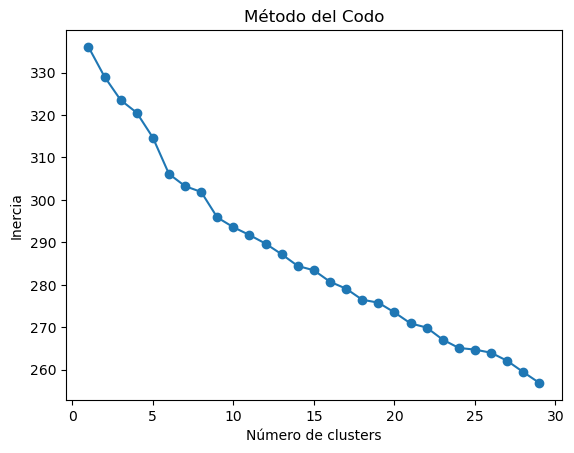

In [15]:
inertia = []
k_range = range(1, 30)
for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(embeddings)
    inertia.append(model.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

El método del codo no dio un resultado; esto puede suceder. 

Usaremos el método silueta. 

- Diferencias: 
    - El método del codo mide la inercia (Within Cluster Sum of Squares) -> qué tan compactos son los cluters. 
    - El método silueta mide: 
        - Qué tan similar es un dato a su propio cluster y qué tan distinto es a los otros clusters

Número óptimo de clusters: 8


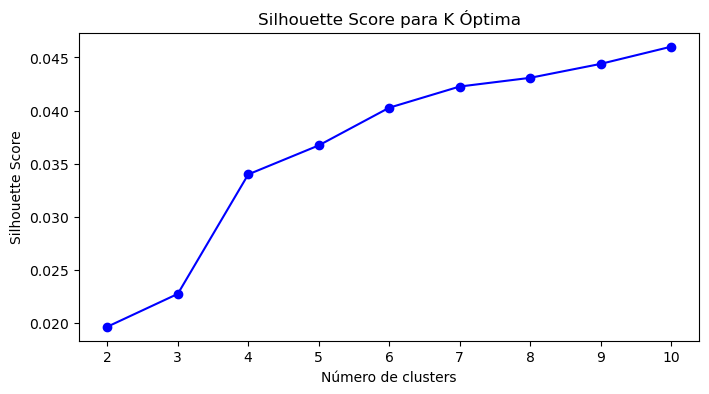

In [24]:
silhouette_scores = []
    
for n_clusters in range(2, min(11, len(embeddings))):
        
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)
        
    silhouette_avg = silhouette_score(embeddings, cluster_labels)
    silhouette_scores.append(silhouette_avg)
   
optimal_clusters = np.argmax(silhouette_scores) 
print(f"Número óptimo de clusters: {optimal_clusters}")
    
plt.figure(figsize=(8, 4))
plt.plot(range(2, 2 + len(silhouette_scores)), silhouette_scores, 'bo-')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score para K Óptima')
plt.show()

Ahora sí, podemos aplicar KMeans

In [25]:
clustering = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
clusters = clustering.fit_predict(embeddings)

df["cluster"] = clusters

In [26]:
df.head()

,title,body,url,score,id,text,preprocessed_texts,cluster
0,Rate My Portfolio - r/Stocks Quarterly Thread ...,Please use this thread to discuss your portfol...,https://www.reddit.com/r/stocks/comments/1j0w7...,30,1j0w73o,Rate My Portfolio - r/Stocks Quarterly Thread ...,rate portfolio rstocks quarterly thread march ...,6
1,r/Stocks Daily Discussion & Technicals Tuesday...,"This is the daily discussion, so anything stoc...",https://www.reddit.com/r/stocks/comments/1jjff...,10,1jjff44,r/Stocks Daily Discussion & Technicals Tuesday...,rstocks daily discussion technicals tuesday ma...,2
2,Tesla just got even more bad news from Europe,"""Tesla's sales in Europe plunged in the first ...",https://www.reddit.com/r/stocks/comments/1jjn4...,2164,1jjn4aa,Tesla just got even more bad news from Europe ...,tesla got even bad news europe teslas sales eu...,0
3,Canada Freezes $43 Million in Tesla EV Rebates...,Paywall Free Source:\n\nhttps://driveteslacana...,https://www.reddit.com/r/stocks/comments/1jjur...,595,1jjurav,Canada Freezes $43 Million in Tesla EV Rebates...,canada freezes million tesla rebates bans futu...,4
4,Retail traders plough $67bn into us stocks whi...,[https://www.ft.com/content/39a6c6c4-a2f5-4ce5...,https://www.reddit.com/r/stocks/comments/1jjmb...,811,1jjmb9k,Retail traders plough $67bn into us stocks whi...,retail traders plough stocks investment giants...,3


### Resultados en DataFrame

In [27]:
df_with_clusters = df.copy()
    
cluster_stats = []
    
for cluster_id in range(len(df_with_clusters['cluster'].unique())):
    cluster_posts = df_with_clusters[df_with_clusters['cluster'] == cluster_id]
        
    all_text = ' '.join([preprocess_text(text) for text in cluster_posts['text']])
    words = all_text.split()
    word_freq = pd.Series(words).value_counts()
    top_words = word_freq.head(10).index.tolist()
        
    cluster_stats.append({
            'cluster_id': cluster_id,
            'post_count': len(cluster_posts),
            'percentage': len(cluster_posts) / len(df) * 100,
            'top_words': top_words,
            'sample_titles': cluster_posts['title'].head(3).tolist()
        })
    
cluster_df = pd.DataFrame(cluster_stats)

In [28]:
cluster_df

,cluster_id,post_count,percentage,top_words,sample_titles
0,0,36,9.917355,"[tesla, teslas, stock, sales, market, company,...",[Tesla just got even more bad news from Europe...
1,1,71,19.559229,"[market, growth, stock, like, markets, stocks,...","[Amazon is a bargain at $205, Is there any log..."
2,2,12,3.305785,"[news, market, fundamentals, daily, options, a...",[r/Stocks Daily Discussion & Technicals Tuesda...
3,3,37,10.192837,"[tariffs, said, trump, market, trade, year, ra...",[Retail traders plough $67bn into us stocks wh...
4,4,43,11.845730,"[said, company, new, billion, year, nvidia, al...",[Canada Freezes $43 Million in Tesla EV Rebate...
5,5,46,12.672176,"[stock, revenue, stocks, market, news, gold, s...","[Why Klarna IPO a big deal?, Moderna stock: Wh..."
6,6,97,26.721763,"[stocks, stock, market, like, buy, shares, yea...",[Rate My Portfolio - r/Stocks Quarterly Thread...
7,7,21,5.785124,"[european, defense, europe, defence, companies...",[Companies in the EU are starting to look for ...


## Observación de Resultados

<Figure size 1200x800 with 0 Axes>

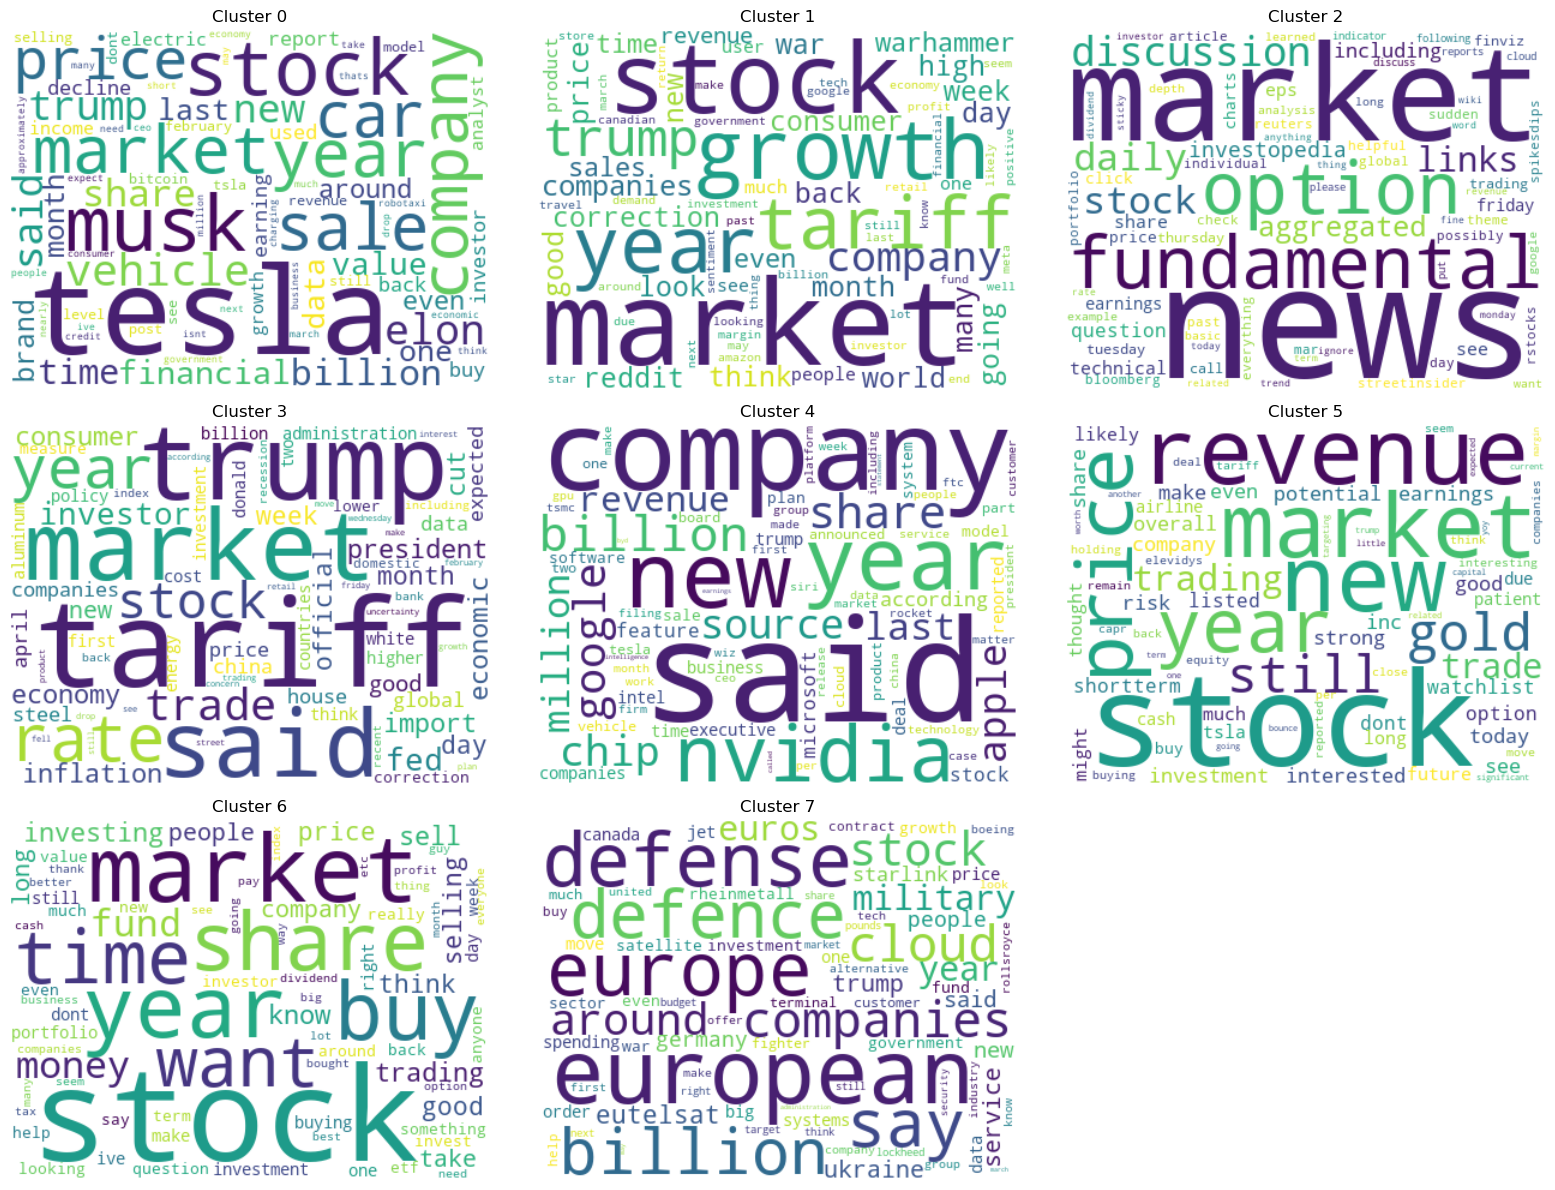

In [29]:
df_with_clusters = df.copy()
cluster_text = {}
for cluster_id in df_with_clusters['cluster'].unique():
    cluster_posts = df_with_clusters[df_with_clusters['cluster'] == cluster_id]
    cluster_text[cluster_id] = ' '.join([preprocess_text(text) for text in cluster_posts['text']])


plt.figure(figsize=(12, 8))


clusters = sorted(cluster_text.keys())
rows, cols = (len(clusters) + 2) // 3, min(3, len(clusters))  

fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
if rows == 1 and cols == 1:
    axes = np.array([axes])  
axes = axes.flatten()


for i, cluster_id in enumerate(clusters):
    if i < len(axes):  
        if len(cluster_text[cluster_id]) > 10:  
            wc = WordCloud(
                width=400, height=300,
                background_color='white',
                max_words=75,
                colormap=f'viridis',
                collocations=False,
                random_state=42
            ).generate(cluster_text[cluster_id])
            
            axes[i].imshow(wc, interpolation='bilinear')
            axes[i].set_title(f'Cluster {cluster_id}')
            axes[i].axis('off')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

---------------------

# Reporte de Laboratorio 04

Ahora realiza una clusterización y una visualización de los clusters sobre los posts del subreddit r/CryptoCurrency. 

El dataset es crypto_stocks.csv

Añade **análisis** a los resultados. 